# Simulated spatial NMC sample

This notebook reconstructs the proposed 10 × 10 mm² sample on the requested 50 × 50 measurement grid. It visualizes the surface atomic fractions and checks how selected positions relax toward bulk NMC811 over a maximum depth of 500,000. No SIMNRA calculation or experimental `.dat` export is performed here.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import ibeamlab as ibl

EXAMPLES = Path.cwd() if (Path.cwd() / 'spatial_sample.py').exists() else Path.cwd() / 'examples'
sys.path.insert(0, str(EXAMPLES.resolve()))
from spatial_sample import ELEMENTS, IMPURITY_SPOTS, MAX_DEPTH, composition, scan_grid

x, y = scan_grid(50)
surface = composition(x, y, 0.0)
print(f'grid: {x.shape}, pitch: {(x[0, 1] - x[0, 0]) * 1000:.2f} µm')
print('maximum normalization error:', np.max(np.abs(surface.sum(axis=-1) - 1.0)))

grid: (50, 50), pitch: 204.08 µm
maximum normalization error: 2.220446049250313e-16


## Reconstructed surface composition

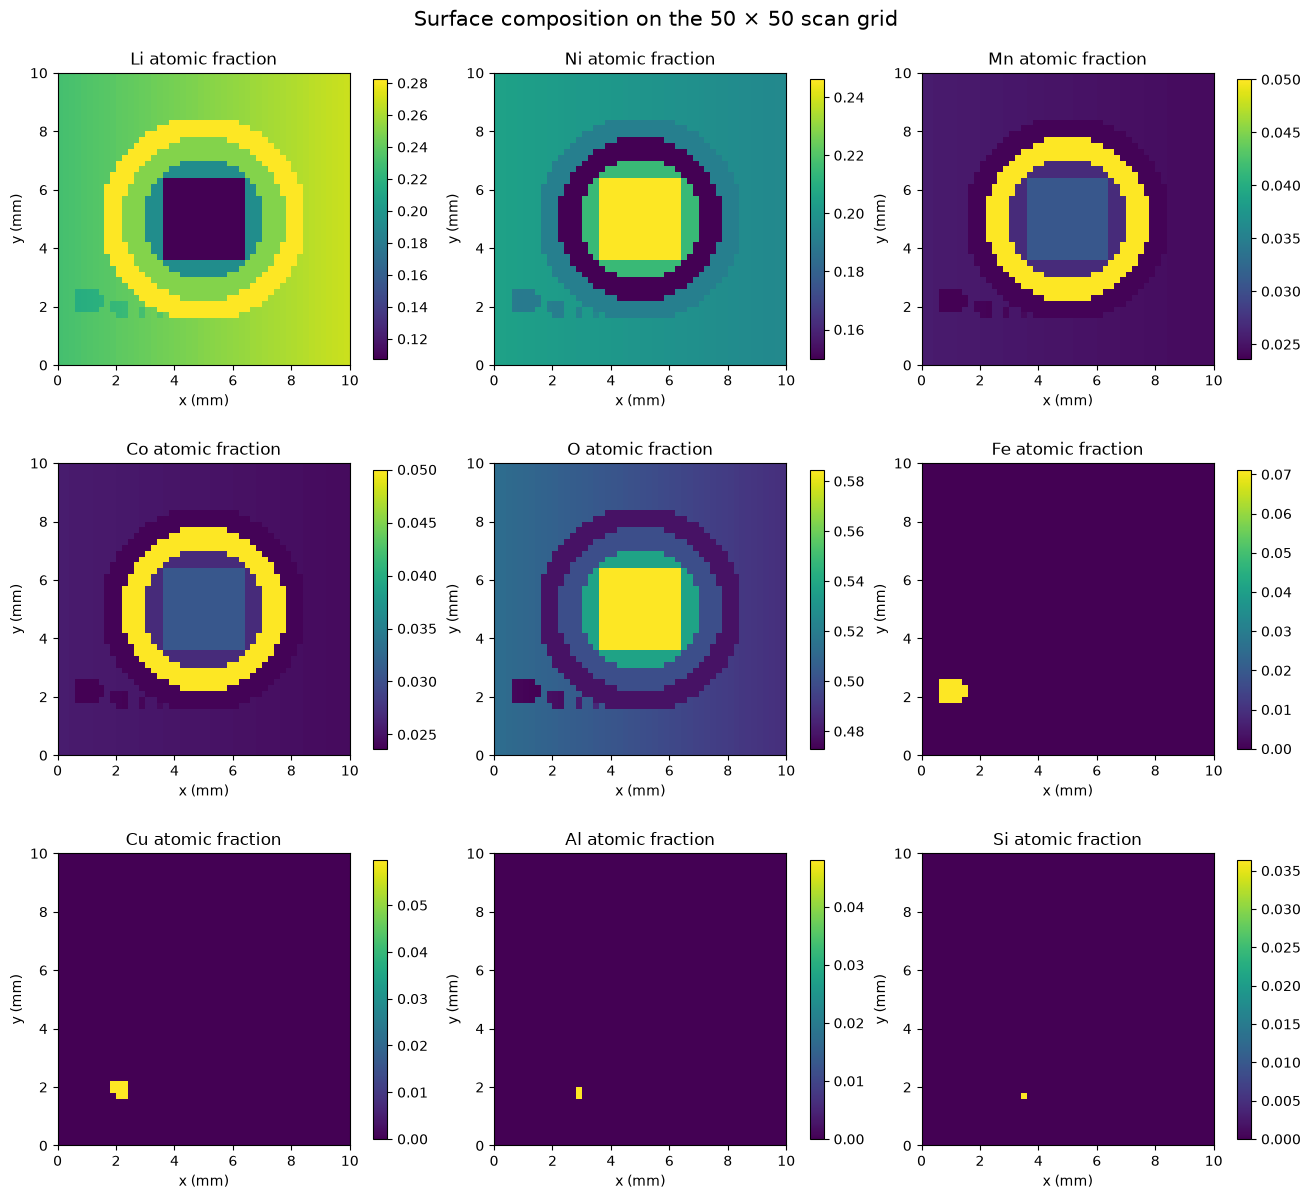

In [2]:
fig, axes = plt.subplots(3, 3, figsize=(13, 12), constrained_layout=True)
for index, (element, ax) in enumerate(zip(ELEMENTS, axes.flat)):
    image = ax.imshow(surface[..., index], origin='lower', extent=(0, 10, 0, 10), cmap='viridis')
    ax.set_title(f'{element} atomic fraction')
    ax.set_xlabel('x (mm)')
    ax.set_ylabel('y (mm)')
    fig.colorbar(image, ax=ax, shrink=0.78)
fig.suptitle('Surface composition on the 50 × 50 scan grid', fontsize=15)
plt.show()

## Layout view

Li is used as the background image, while the colored circles mark the four impurity masks.

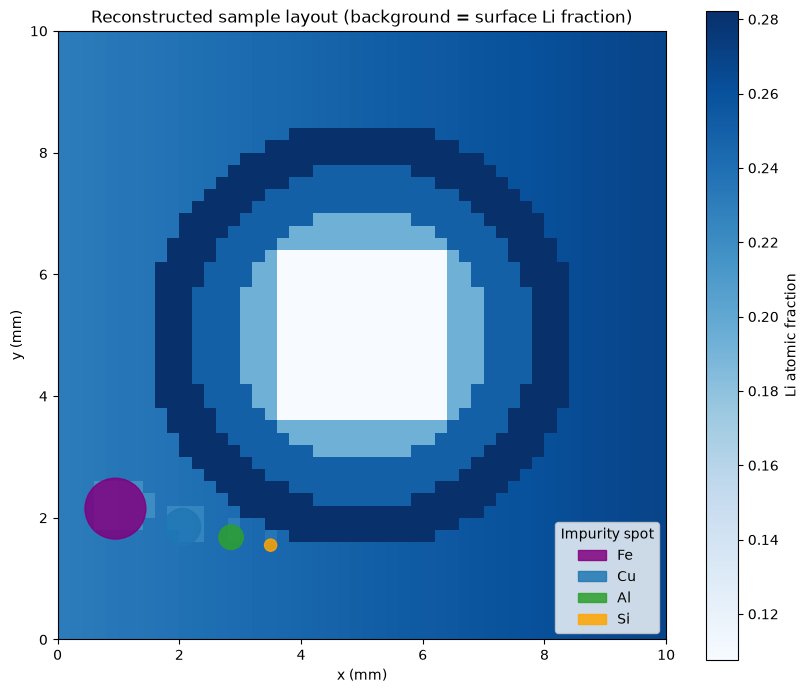

In [3]:
fig, ax = plt.subplots(figsize=(8, 7), constrained_layout=True)
li = surface[..., ELEMENTS.index('Li')]
image = ax.imshow(li, origin='lower', extent=(0, 10, 0, 10), cmap='Blues')
colors = {'Fe': 'purple', 'Cu': 'tab:blue', 'Al': 'tab:green', 'Si': 'orange'}
for element, cx, cy, diameter, _, _ in IMPURITY_SPOTS:
    circle = plt.Circle((cx, cy), diameter / 2, color=colors[element], alpha=0.85, label=element)
    ax.add_patch(circle)
ax.set(xlim=(0, 10), ylim=(0, 10), aspect='equal', xlabel='x (mm)', ylabel='y (mm)',
       title='Reconstructed sample layout (background = surface Li fraction)')
ax.legend(title='Impurity spot', loc='lower right')
fig.colorbar(image, ax=ax, label='Li atomic fraction')
plt.show()

## Representative depth profiles

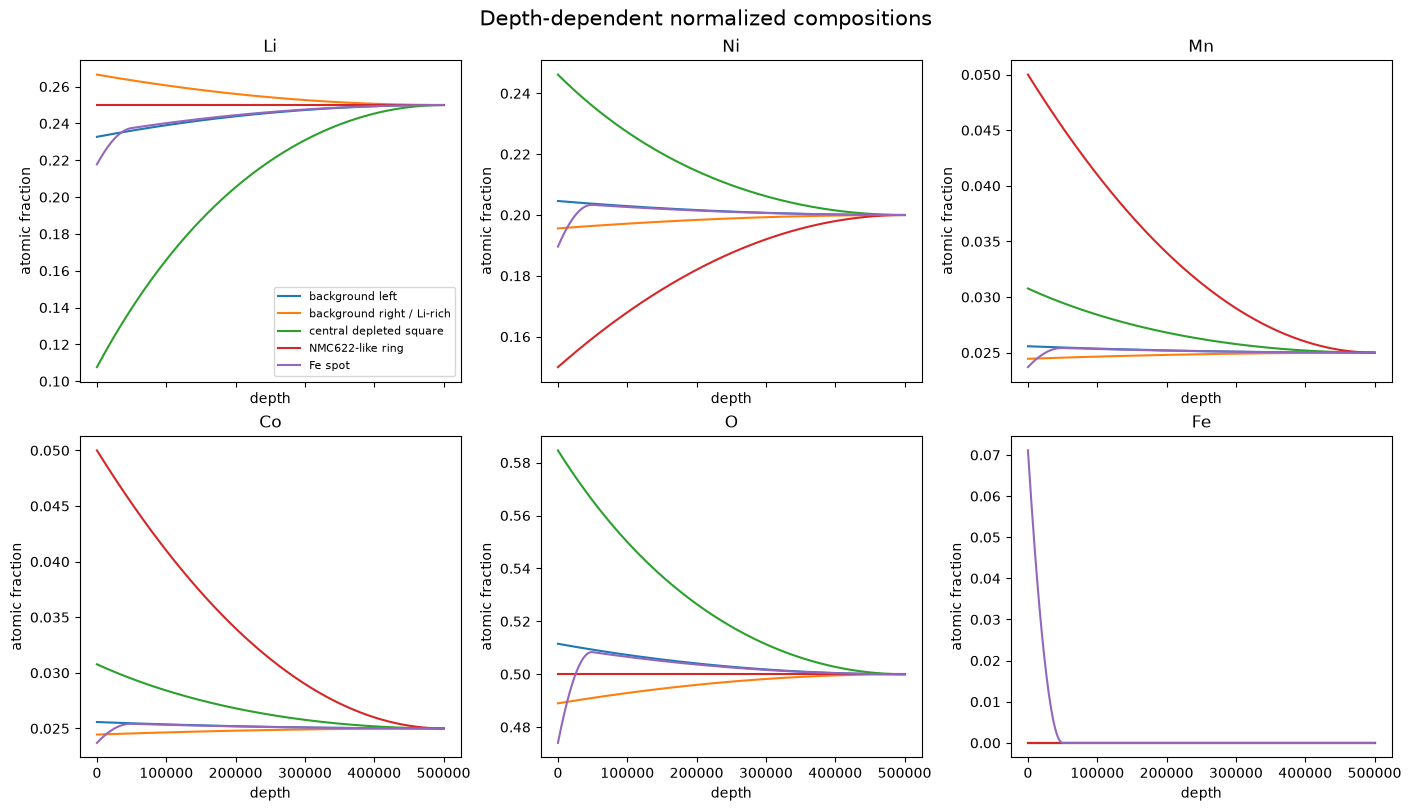

In [4]:
depth = np.linspace(0, MAX_DEPTH, 301)
locations = {
    'background left': (0.5, 8.5),
    'background right / Li-rich': (9.5, 8.5),
    'central depleted square': (5.0, 5.0),
    'NMC622-like ring': (5.0, 7.5),
    'Fe spot': (0.95, 2.15),
}
selected = ('Li', 'Ni', 'Mn', 'Co', 'O', 'Fe')
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, constrained_layout=True)
for label, (px, py) in locations.items():
    profile = composition(px, py, depth)
    for element, ax in zip(selected, axes.flat):
        ax.plot(depth, profile[:, ELEMENTS.index(element)], label=label)
for element, ax in zip(selected, axes.flat):
    ax.set_title(element)
    ax.set_xlabel('depth')
    ax.set_ylabel('atomic fraction')
axes.flat[0].legend(fontsize=8)
fig.suptitle('Depth-dependent normalized compositions', fontsize=15)
plt.show()

In [ ]:
# Materialize one position as a public iBeamLab experiment.
center = composition(5.0, 5.0, 0.0)
sample = ibl.Sample([ibl.Layer(MAX_DEPTH, dict(zip(ELEMENTS, center, strict=True)))])
experiment = ibl.Experiment(sample, [
    ibl.Detector('RBS', ibl.Beam('H', 2974), resolution=20)
])
result = ibl.DummySimulator(channels=256).simulate(experiment)
print(sample)
print('dummy spectrum shape:', result['RBS'].counts.shape)